# Phase 4: Model Explainability with SHAP
## Santander Product Recommendation — Next Product to Buy

**Objective:** Understand WHY the model makes its predictions. This is critical for:
- Business stakeholders: "Why should we target this customer for Credit Card?"
- Model validation: Are the drivers sensible?
- Regulatory compliance: Explainable AI in banking
- QNB Interview: Demonstrates analytical maturity beyond just accuracy

In [1]:
import pandas as pd
import numpy as np
import json
import shap
import lightgbm as lgb
import xgboost as xgb
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

PROCESSED_PATH = Path('../data/processed')
MODEL_PATH = Path('../models')

# Load data
val_df = pd.read_parquet(PROCESSED_PATH / 'val.parquet')
with open(PROCESSED_PATH / 'feature_cols.json') as f:
    feature_cols = json.load(f)
with open(MODEL_PATH / 'metadata.json') as f:
    metadata = json.load(f)

X_val = val_df[feature_cols]

# Sample for SHAP (full dataset is too slow)
SHAP_SAMPLE = 5000
np.random.seed(42)
sample_idx = np.random.choice(len(X_val), min(SHAP_SAMPLE, len(X_val)), replace=False)
X_sample = X_val.iloc[sample_idx]

print(f'Validation set: {X_val.shape}')
print(f'SHAP sample: {X_sample.shape}')

Validation set: (926760, 95)
SHAP sample: (5000, 95)


In [2]:
# Load best models
product_names_map = {
    'cco_fin': 'Current Account', 'recibo': 'Direct Debit',
    'tjcr_fin': 'Credit Card', 'nomina': 'Payroll',
    'nom_pens': 'Pensions (Payroll)', 'ecue_fin': 'e-Account',
    'cno_fin': 'Payroll Account', 'reca_fin': 'Taxes',
    'ctop_fin': 'Particular Account', 'dela_fin': 'Long-term Deposits',
    'ctma_fin': 'Más Particular Account', 'valo_fin': 'Securities',
    'fond_fin': 'Funds', 'ctpp_fin': 'Particular Plus Account',
}

# Pick top 5 products by AUC for detailed SHAP analysis
top_products = sorted(metadata['models'].items(), key=lambda x: x[1]['auc'], reverse=True)[:5]
print('Top 5 products for SHAP analysis:')
for target, info in top_products:
    product_short = target.replace('_added', '').replace('ind_', '').replace('_ult1', '')
    print(f"  {product_names_map.get(product_short, product_short)}: AUC={info['auc']:.4f} ({info['type']})")

Top 5 products for SHAP analysis:
  ctju_fin: AUC=1.0000 (xgb)
  Más Particular Account: AUC=0.9945 (xgb)
  Current Account: AUC=0.9896 (xgb)
  Particular Account: AUC=0.9746 (xgb)
  Payroll: AUC=0.9714 (xgb)


## 1. Global Feature Importance (SHAP Summary)


SHAP Summary: ctju_fin


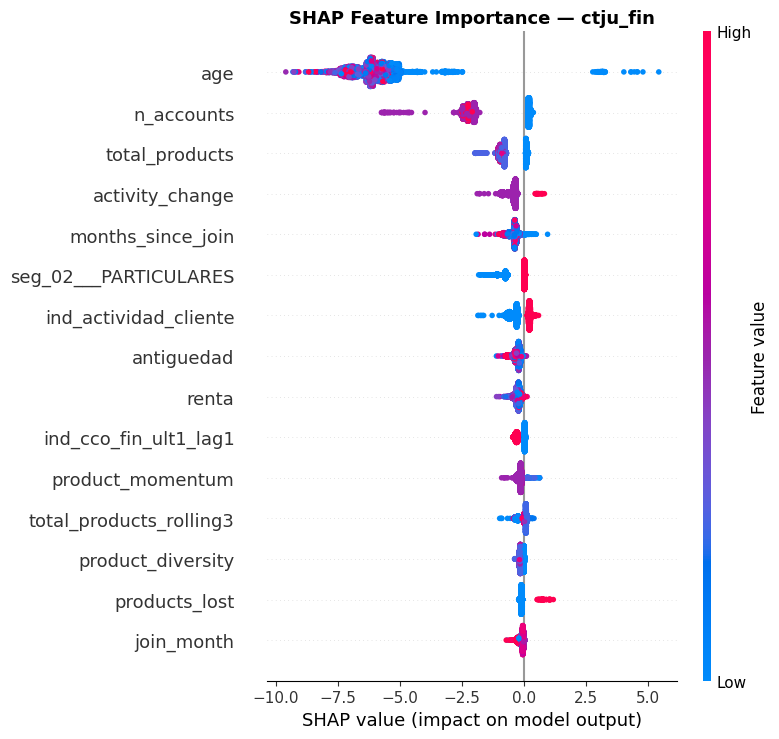


SHAP Summary: Más Particular Account


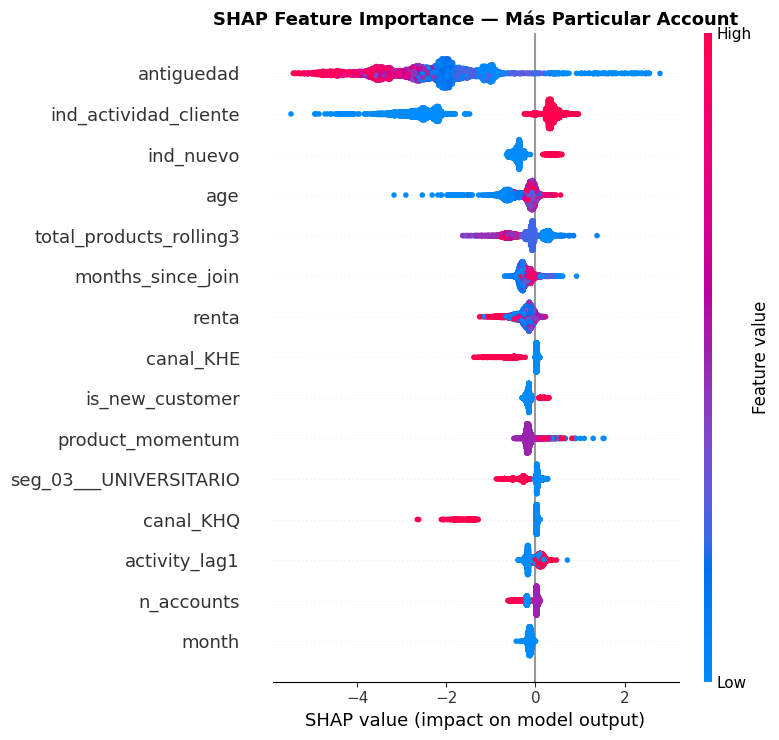


SHAP Summary: Current Account


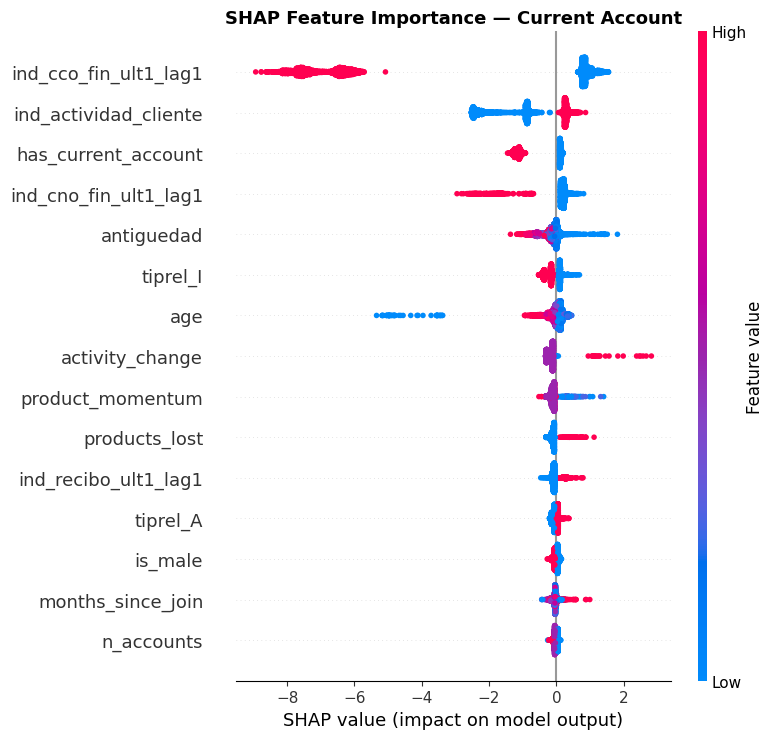


SHAP Summary: Particular Account


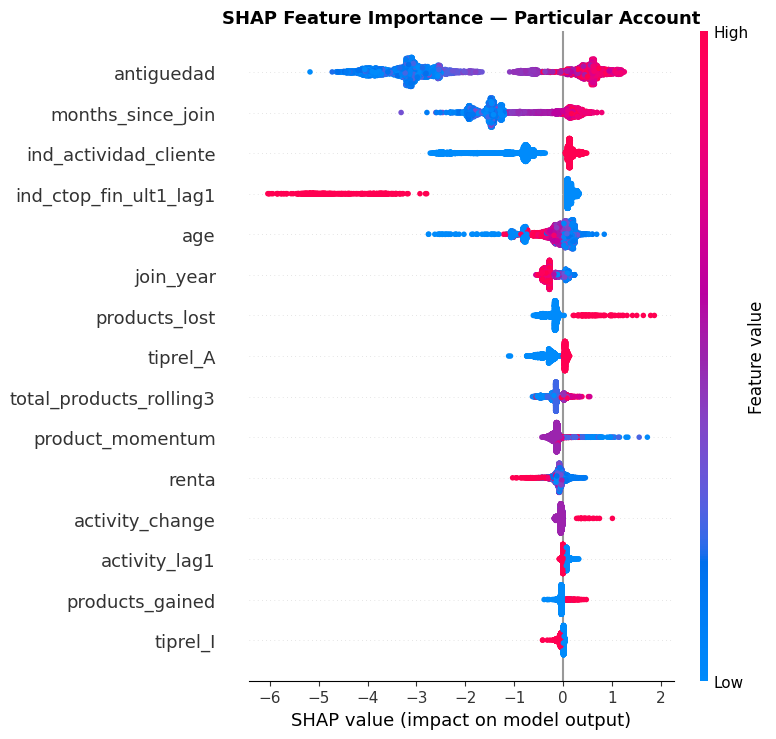


SHAP Summary: Payroll


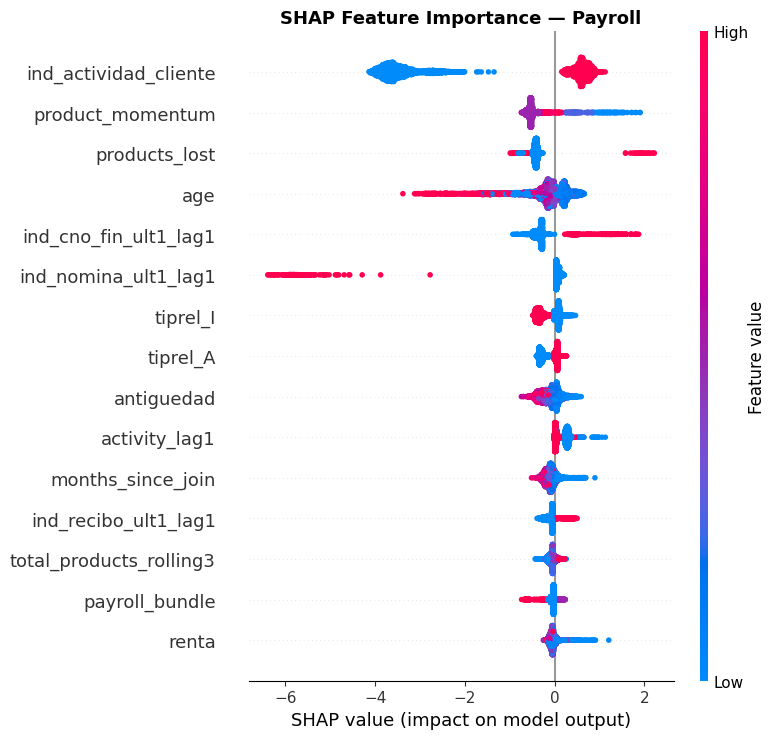

In [3]:
shap_values_dict = {}

for target, info in top_products:
    product_short = target.replace('_added', '').replace('ind_', '').replace('_ult1', '')
    product_label = product_names_map.get(product_short, product_short)
    
    # Load model
    if info['type'] == 'lgb':
        model = lgb.Booster(model_file=str(MODEL_PATH / f'{product_short}_lgb.txt'))
        explainer = shap.TreeExplainer(model)
    else:
        model = xgb.Booster()
        model.load_model(str(MODEL_PATH / f'{product_short}_xgb.json'))
        explainer = shap.TreeExplainer(model)
    
    # Compute SHAP values
    sv = explainer.shap_values(X_sample)
    shap_values_dict[product_label] = sv
    
    # Summary plot
    print(f'\n{"="*60}')
    print(f'SHAP Summary: {product_label}')
    print(f'{"="*60}')
    
    plt.figure(figsize=(10, 8))
    shap.summary_plot(sv, X_sample, max_display=15, show=False)
    plt.title(f'SHAP Feature Importance — {product_label}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'../outputs/shap_summary_{product_short}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 2. SHAP Bar Plot (Mean Absolute Impact)

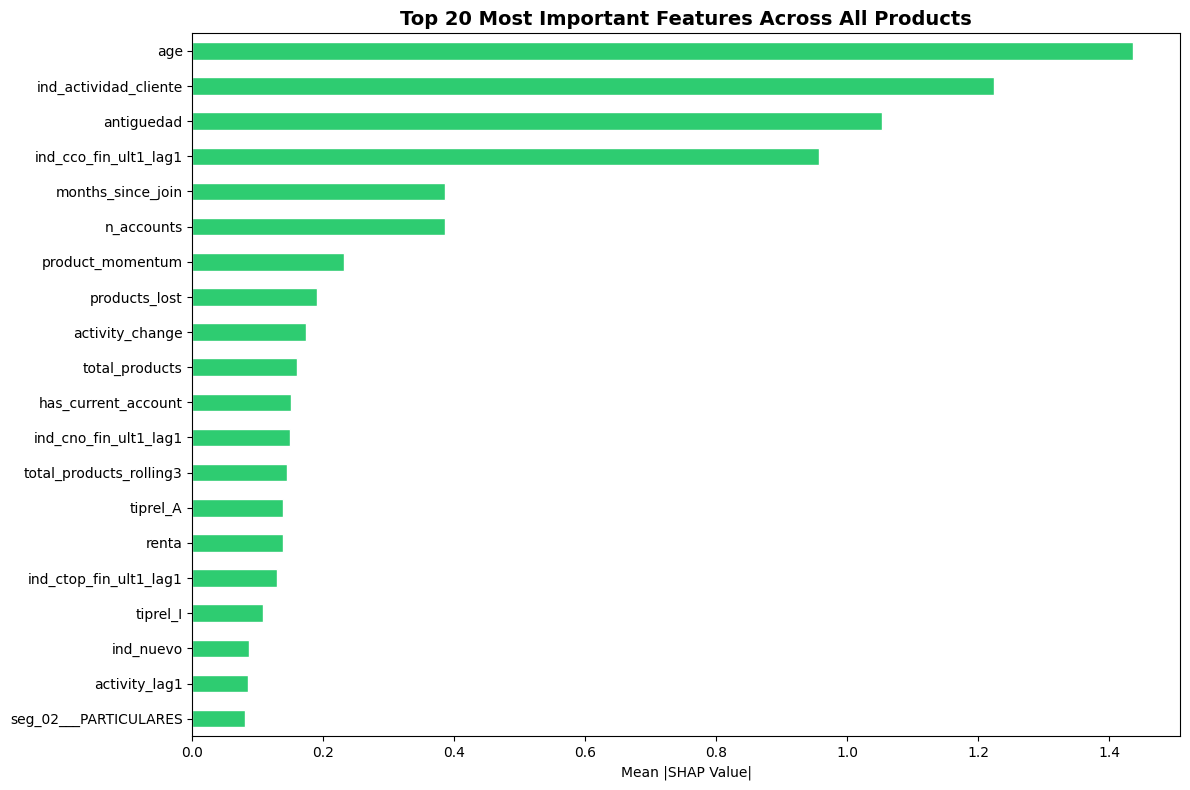

In [4]:
# Combined feature importance across all top products
importance_combined = pd.DataFrame()

for product_label, sv in shap_values_dict.items():
    mean_abs_shap = np.abs(sv).mean(axis=0)
    imp = pd.Series(mean_abs_shap, index=feature_cols, name=product_label)
    importance_combined[product_label] = imp

# Overall importance (average across products)
importance_combined['Overall'] = importance_combined.mean(axis=1)
top20_features = importance_combined.nlargest(20, 'Overall')

fig, ax = plt.subplots(figsize=(12, 8))
top20_overall = top20_features['Overall'].sort_values(ascending=True)
top20_overall.plot(kind='barh', ax=ax, color='#2ecc71', edgecolor='white')
ax.set_xlabel('Mean |SHAP Value|')
ax.set_title('Top 20 Most Important Features Across All Products', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/shap_overall_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Individual Customer Explanations (Waterfall Plots)

In [5]:
# Pick the first product (highest AUC) for individual explanations
main_product = list(shap_values_dict.keys())[0]
main_sv = shap_values_dict[main_product]
main_target = top_products[0][0]

# Find a customer who actually added this product (true positive case)
y_actual = val_df.iloc[sample_idx][main_target].values
positive_indices = np.where(y_actual == 1)[0]

if len(positive_indices) > 0:
    # Show waterfall for first positive case
    idx = positive_indices[0]
    
    print(f'Customer who added {main_product}:')
    print(f'  Age: {X_sample.iloc[idx]["age"]:.0f}' if 'age' in X_sample.columns else '')
    print(f'  Total products (lag): {X_sample.iloc[idx].get("total_products_lag1", "N/A")}')
    
    # Waterfall plot
    shap_explanation = shap.Explanation(
        values=main_sv[idx],
        base_values=main_sv[idx].sum() - main_sv[idx].sum() + np.mean(main_sv.sum(axis=1)),  # approximate
        data=X_sample.iloc[idx].values,
        feature_names=feature_cols
    )
    
    plt.figure(figsize=(10, 8))
    shap.waterfall_plot(shap_explanation, max_display=15, show=False)
    plt.title(f'Why This Customer Added {main_product}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../outputs/shap_waterfall_example.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f'No positive examples in sample for {main_product}')

No positive examples in sample for ctju_fin


## 4. SHAP Dependence Plots (Feature Interactions)

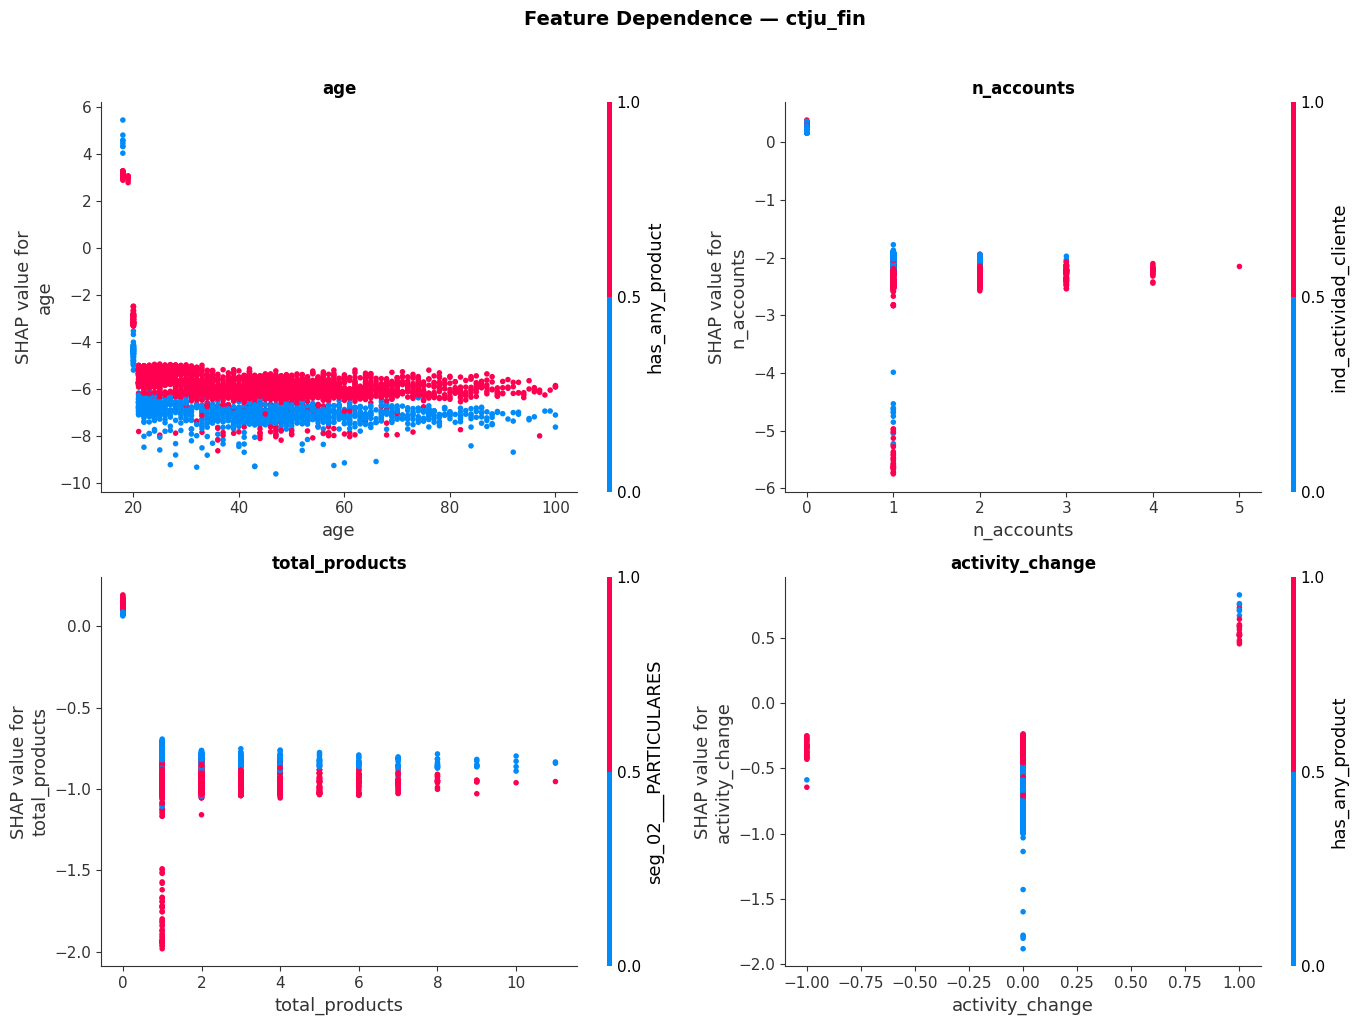

In [6]:
# Show dependence plots for top 4 features of main product
main_importance = np.abs(main_sv).mean(axis=0)
top4_idx = np.argsort(-main_importance)[:4]
top4_features = [feature_cols[i] for i in top4_idx]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, feat_name, feat_idx in zip(axes.flat, top4_features, top4_idx):
    shap.dependence_plot(
        feat_idx, main_sv, X_sample,
        feature_names=feature_cols,
        ax=ax, show=False
    )
    ax.set_title(f'{feat_name}', fontweight='bold')

plt.suptitle(f'Feature Dependence — {main_product}', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Faz 4'ten importance_combined değişkeni varsa
importance_export = importance_combined['Overall'].nlargest(20).reset_index()
importance_export.columns = ['feature', 'ort_shap']
importance_export.to_csv('../data/processed/powerbi_shap.csv', index=False)
print(importance_export)

                    feature  ort_shap
0                       age  1.436674
1     ind_actividad_cliente  1.224033
2                antiguedad  1.053549
3     ind_cco_fin_ult1_lag1  0.957197
4         months_since_join  0.385968
5                n_accounts  0.385535
6          product_momentum  0.231625
7             products_lost  0.189636
8           activity_change  0.174030
9            total_products  0.159557
10      has_current_account  0.149872
11    ind_cno_fin_ult1_lag1  0.148858
12  total_products_rolling3  0.145034
13                 tiprel_A  0.138463
14                    renta  0.137770
15   ind_ctop_fin_ult1_lag1  0.129843
16                 tiprel_I  0.108096
17                ind_nuevo  0.086923
18            activity_lag1  0.084943
19    seg_02___PARTICULARES  0.080027
